In [44]:
from unitarylab.core import Circuit
from unitarylab.library._qft import QFT, IQFT
from unitarylab.library.block_encoding import block_encode
from numpy.polynomial.chebyshev import chebval
import time
import os
import sys
import numpy as np
import mpmath as mp
from unitarylab.library._qsp import QSP
import matplotlib.pyplot as plt
from typing import Dict, Any, List, Tuple

# 1. Fourier Spectral method for biharmonic equation

In [45]:
# Construct Linear system and source term
def laplace_d(N):
    L = 2.0
    k_int = np.fft.fftfreq(N) * N
    k_phys = (2 * np.pi / L) * k_int  # k_phys = pi * k

    # 二阶导数对角矩阵的对角线元素 Lambda^{(2)} = -k^2
    laplace_diag = -(k_phys**2)
    laplace_diag[0] = np.pi ** 2
    d = np.diag(laplace_diag)
    return d

def fft_source(N):
    x = np.linspace(-1, 1, N, endpoint=False)
    f = (np.pi**4) * np.sin(np.pi * x) + 16 * (np.pi**4) * np.cos(2 * np.pi * x)
    return f

def expanded_a(N):
    L = laplace_d(N)
    I = np.eye(N)
    Z = np.zeros((N, N))
    A = np.block([[L, -I], [Z, L]])
    return A

In [46]:
def _b_value(kappa: float, alpha: float, epsilon: float) -> float:
    """Compute the auxiliary parameter ``b`` used by the Chebyshev coefficient formula.

    Args:
        kappa (float): Condition number of the matrix.
        alpha (float): Block-encoding normalization factor.
        epsilon (float): Target approximation error.

    Returns:
        float: The value ``ceil((kappa * alpha)^2 * log(kappa * alpha / epsilon))``.
    """
    return np.ceil((kappa * alpha)**2 * np.log(kappa * alpha / epsilon))

def _j_0_value(b: float, epsilon: float) -> float:
    """Compute the truncation index ``j_0`` for the Chebyshev series.

    Args:
        b (float): Auxiliary parameter from :func:`_b_value`.
        epsilon (float): Target approximation error.

    Returns:
        float: The value ``ceil(sqrt(b * log(4b / epsilon)))``.
    """
    return np.ceil(np.sqrt(b * np.log(4 * b / epsilon)))

def _central_binom_ratio(b: float, dps: int = 50) -> float:
    """Compute the central binomial ratio ``C(2b, b) / 4^b`` in high precision.

    Args:
        b (float): Parameter (treated as an integer internally).
        dps (int): Decimal places for ``mpmath`` precision. Defaults to ``50``.

    Returns:
        float: The ratio ``C(2b, b) / 4^b`` evaluated in ``mpmath`` precision.
    """
    mp.mp.dps = dps
    b_int = int(b)
    logR = mp.loggamma(2*b_int + 1) - 2*mp.loggamma(b_int + 1) - b_int*mp.log(4)
    return float(mp.e**logR)

def _chebyshev_factor(kappa: float, alpha: float, epsilon: float, beta: float = 2.) -> np.ndarray:
    """Compute Chebyshev expansion coefficients of ``f(x) = (1-(1-x^2)^b)/x``.

    Args:
        kappa (float): Condition number of the matrix.
        alpha (float): Block-encoding normalization factor.
        epsilon (float): Target approximation error.
        beta (float): Stability scaling factor. Defaults to ``2.0``.

    Returns:
        numpy.ndarray: Array of Chebyshev coefficients normalized by
            ``1 / (beta * kappa * alpha)``.
    """
    b = _b_value(kappa, alpha, epsilon)
    j = _j_0_value(b, epsilon)

    mid_v = _central_binom_ratio(b)
    value = (1. - mid_v) / 2.
    j = int(j) + 1

    coefficient_list = np.zeros(j, dtype=float)
    for k in range(j):
        coefficient_list[k] = 4 * (-1) ** k * value
        mid_v = mid_v * (b - k) / (b + k + 1)
        value -= mid_v
    return coefficient_list / (beta * kappa * alpha)

def _indicator(kappa, alpha, epsilon, beta=2.):
    """Return Chebyshev coefficients with adaptive beta for numerical stability.

    Rescales ``beta`` if the maximum value of the odd Chebyshev series on
    ``[0, 1/(kappa*alpha-1)]`` exceeds 1.

    Args:
        kappa (float): Condition number of the matrix.
        alpha (float): Block-encoding normalization factor.
        epsilon (float): Target approximation error.
        beta (float): Initial stability scaling factor. Defaults to ``2.0``.

    Returns:
        tuple[numpy.ndarray, float]: A 2-tuple ``(coefficients, beta)`` where
            ``coefficients`` is the (possibly rescaled) coefficient array and
            ``beta`` is the final scaling factor used.
    """
    c_list = _chebyshev_factor(kappa, alpha, epsilon, beta)
    x_test = np.linspace(0, 1./(kappa * alpha - 1), 100)
    val_max = np.max(_eval_cheb_odd_series(c_list, x_test))
    if val_max > 1:
        beta = 2.5 * val_max
        return _chebyshev_factor(kappa, alpha, epsilon, beta), beta
    else:
        return c_list, beta

def _eval_cheb_odd_series(c, x):
    """Evaluate an odd Chebyshev series ``f(x) = sum_k c[k] * T_{2k+1}(x)``.

    Args:
        c (array-like): Coefficient array where ``c[k]`` multiplies ``T_{2k+1}(x)``
            (no ``T_0`` term).
        x (array-like): Points at which to evaluate the series.

    Returns:
        numpy.ndarray: Evaluated series values at each point in ``x``.
    """
    c = np.asarray(c, dtype=float)
    x = np.asarray(x, dtype=float)
    K = c.size
    a = np.zeros(2*K + 1, dtype=float)  # a[0] corresponds to T0, fixed to 0 here
    a[1::2] = c
    # print(a)  # fill in odd-degree coefficients: 1, 3, 5, ...
    return chebval(x, a)


Consider 1d problem with exact solution $u(x)=\sin(\pi x)+\cos(2\pi x).$

In [47]:
# Construct quantum circuit

def one_d_solver(N, logging: bool = True):
    #N is the number of collocation points
    A = expanded_a(N)
    A = np.array(A)
    na = np.linalg.norm(A, 2)
    b = fft_source(N)
    A = A / na
    b = b / na

    # Validate input
    norm_b = np.linalg.norm(b)
    if norm_b == 0:
        raise ValueError("Source vector b cannot be all zeros!")

    # Build block-encoding circuit for A
    Block_A = block_encode(A, 'nagy')
    kappa = np.linalg.cond(A)
    n_sys = int(np.ceil(np.log2(A.shape[0])))
    alpha = Block_A.alpha
    gs_be = Block_A.circuit
    n_anc_be = 1
    total_qubits = n_sys + n_anc_be + 1
    gs = Circuit(total_qubits)
    b_state = b / norm_b
    gs.initialize(b_state,list(range(n_sys - 1)))
    gs.x(n_sys-1)
    gs.append(QFT(n_sys - 1), list(range(n_sys - 1)))

    epsilon = 1e-12

    log_prefix = "[QSVT_QLSA] " if logging else ""
    if logging:
        print("=" * 70)
        print(f"{log_prefix}Starting QSVT linear solver (target precision={epsilon})")
        print("=" * 70)

    # ================= Stage 1 =================
    if logging:
        print("=" * 50)
        print(f"{log_prefix}Stage 1/4: Classical preprocessing (computing Chebyshev approximation coefficients)...")

    # Compute truncated Chebyshev expansion coefficients for f(x) = 1/x
    beta = 2.
    c_chebyshev, beta2 = _indicator(kappa, alpha, epsilon, beta)
    k_degree = len(c_chebyshev) * 2 - 1

    # Assemble full coefficient array (odd-degree terms only)
    c_array = np.asarray(c_chebyshev, dtype=float)
    a_chebyshev = np.zeros(2 * len(c_array), dtype=float)
    a_chebyshev[1::2] = c_array

    print(f"  - Matrix condition number (kappa): {kappa}")
    print(f"  - Block-Encoding factor (alpha): {alpha}")
    print(f"  - Highest truncated polynomial degree: {k_degree}")
    print(f"{log_prefix}Stage 1/4 complete ✓")

    # ================= Stage 2 =================
    if logging:
        print("=" * 50)
        print(f"{log_prefix}Stage 2/4: Building QSVT quantum circuit...")

    # 2. Generate QSP/QSVT processing sequence
    if logging:
        print(f"  - Calling QSP engine to generate polynomial Block-Encoding circuit...")

    # Note: the inverse of gs_be (U_A†) is passed here.
    # Exact parameter requirements depend on the QSP_block_encoding implementation.
    qsp_circ = QSP(gs_be.dagger(), n_sys, n_anc_be, coef=a_chebyshev, parity=1, is_coef_cheby=True)

    gs.append(qsp_circ, list(range(total_qubits)))
    if logging:
        print(f"{log_prefix}Stage 2/4 complete ✓")

    # ================= Stage 3 =================
    if logging:
        print("=" * 50)
        print(f"{log_prefix}Stage 3/4: Running quantum simulation...")

    device = "cpu"
    gs.append(IQFT(n_sys-1), list(range(n_sys - 1)))
    sim_start = time.time()
    final_state = gs.execute(device=device).state
    state_arr = np.asarray(final_state, dtype=complex).reshape(-1)
    sim_time = time.time() - sim_start

    if logging:
        print(f"  - Core simulation time: {sim_time:.4f} s")
        print(f"{log_prefix}Stage 3/4 complete ✓")

    # ================= Stage 4 =================
    if logging:
        print("=" * 50)
        print(f"{log_prefix}Stage 4/4: Running classical post-processing (restoring scaling factor and extracting solution)...")

    # Extract system-register amplitudes (first 2^n_sys elements).
    # Assumes ancilla qubits |0> correspond to the first 2^n entries,
    # consistent with the QSP module's ancilla ordering convention.
    raw_solution = state_arr[0 : 2**n_sys]
    #print(np.linalg.norm(raw_solution))

    # Restore physical scaling factor.
    # Multiply by beta because f(x) ≈ 1/(beta·κ·α·x) keeps values in [-1, 1].
    scaling_factor = norm_b * kappa * beta2
    final_solution = raw_solution * scaling_factor

    # Compute validation metric (norm for reference; compare externally if exact solution is available).
    sol_norm = np.linalg.norm(final_solution)

    if logging:
        print(f"  - Extracted raw quantum amplitudes and applied scaling factor: {scaling_factor:.4f}")
        print(f"  - Norm of solved vector: ||x|| = {sol_norm:.4f}")
        print(f"{log_prefix}Stage 4/4 complete ✓")
        print(f"{log_prefix}Solution vector:")
        print(final_solution)

    return np.real(final_solution[:8])




In [48]:
# Set up the format of the plot
plt.style.use("default")
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "savefig.edgecolor": "white",
    "axes.edgecolor": "black",
    "axes.labelcolor": "black",
    "axes.titlecolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "text.color": "black",
    "grid.color": "0.72",
    "grid.linestyle": ":",
    "grid.linewidth": 0.8,
    "legend.facecolor": "white",
    "legend.edgecolor": "black",
    "legend.framealpha": 1.0,
})

[QSVT_QLSA] Starting QSVT linear solver (target precision=1e-12)
[QSVT_QLSA] Stage 1/4: Classical preprocessing (computing Chebyshev approximation coefficients)...
  - Matrix condition number (kappa): 16.884464701305642
  - Block-Encoding factor (alpha): 1.0
  - Highest truncated polynomial degree: 1153
[QSVT_QLSA] Stage 1/4 complete ✓
[QSVT_QLSA] Stage 2/4: Building QSVT quantum circuit...
  - Calling QSP engine to generate polynomial Block-Encoding circuit...
[QSVT_QLSA] Stage 2/4 complete ✓
[QSVT_QLSA] Stage 3/4: Running quantum simulation...
  - Core simulation time: 0.1480 s
[QSVT_QLSA] Stage 3/4 complete ✓
[QSVT_QLSA] Stage 4/4: Running classical post-processing (restoring scaling factor and extracting solution)...
  - Extracted raw quantum amplitudes and applied scaling factor: 1465.5267
  - Norm of solved vector: ||x|| = 81.4361
[QSVT_QLSA] Stage 4/4 complete ✓
[QSVT_QLSA] Solution vector:
[ 9.99977395e-01+6.99106808e-08j -7.07117217e-01-1.64635822e-06j
 -1.99999215e+00-2.36022

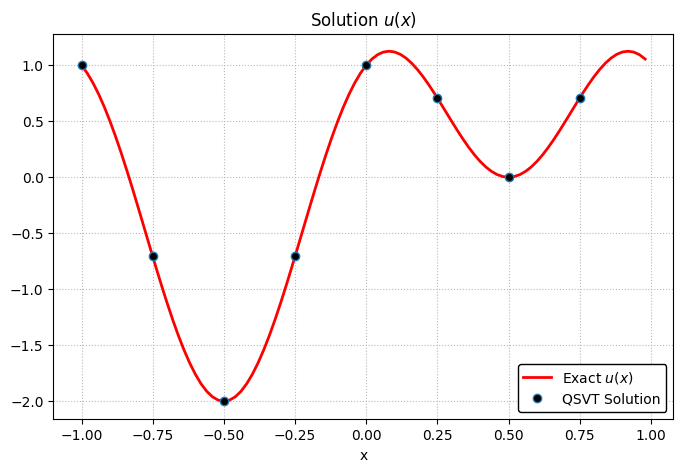

In [49]:
# Run the quantum simulation and plot the result
u_num = one_d_solver(8)

print(u_num)

x_exact = np.linspace(-1, 1, 100, endpoint=False)

x_mesh  =  np.linspace(-1, 1, 8, endpoint=False)

u_exact = np.sin(np.pi * x_exact) + np.cos(2 * np.pi * x_exact)

u_mesh = np.sin(np.pi * x_mesh) + np.cos(2 * np.pi * x_mesh)

error_u = np.max(np.abs(u_num - u_mesh))

print(f"最终解 u 的最大误差 (L-inf): {error_u:.5e}")

plt.figure(figsize=(8, 5))

# 绘制最终解 u
plt.plot(x_exact, u_exact, 'r-', linewidth=2, label='Exact $u(x)$')
plt.plot(x_mesh, u_num, 'o', markerfacecolor='black', label='QSVT Solution')
plt.title('Solution $u(x)$')
plt.xlabel('x')
plt.legend()
plt.grid(True)
plt.savefig('qsvt_bi.pdf', bbox_inches='tight')
plt.show()

# 2. Simply Supported Boundary Condition



In [89]:
from scipy.fft import dst, idst
def dst_matrix(N):
    # N =2^k-1
    dx = 1./ (N + 1)
    k = np.arange(0, N + 1)
    lambda_k = (2 * np.cos(k * np.pi / (N + 1)) - 2) / (dx**2)
    lambda_k[0] = lambda_k[1]
    return np.diag(lambda_k)

def dst_source_1(N):
    x = np.linspace(0, 1, N + 2)[1:-1]
    f = (np.pi**4) * np.sin(np.pi * x) + 40.5 * (np.pi**4) * np.sin(3 * np.pi * x)
    f_hat = dst(f / np.linalg.norm(f), type=1, norm='ortho')
    f_expand = np.zeros(N + 1)
    f_expand[1:] = f_hat
    return f_expand

def dst_source(N):
    x = np.linspace(0, 1, N + 2)[1:-1]
    f = (np.pi**4) * np.sin(np.pi * x) + 40.5 * (np.pi**4) * np.sin(3 * np.pi * x)
    f_expand = np.zeros(N + 1)
    f_expand[1:] = f
    return f_expand

def expand_dst_a(N):
    L = dst_matrix(N)
    I = np.eye(N+1)
    Z = np.zeros((N+1, N+1))
    A = np.block([[L, -I], [Z, L]])
    return A

B = dst_matrix(15)
A = expand_dst_a(15)
f1 = np.zeros(32)
f1[16: ] = dst_source_1(15)
print(f1)
u = np.linalg.solve(A, f1)
print(u[1:16])
print(idst(u[1:16], type = 1, norm = "ortho"))

u_1 = np.linalg.solve(B, dst_source(15))
u_2 = np.linalg.solve(B, u_1)
print(idst(u_2[1:], type = 1, norm = "ortho"))


[ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  2.46838348e-02  1.30384264e-16  9.99695308e-01
 -1.61176087e-16 -4.89556563e-17  4.40572325e-17  4.32825877e-19
 -1.47196168e-17  1.03470143e-16 -4.15905463e-17 -4.89556563e-17
  1.54593148e-17 -0.00000000e+00 -3.37681382e-17  3.18925031e-17]
[ 2.55037831e-04  8.58385480e-20  1.34267620e-04 -7.16707669e-21
 -9.45489426e-22  4.41023190e-22  2.54846690e-24 -5.61508820e-23
  2.76359037e-22 -8.29868317e-23 -7.71762562e-23  2.02361991e-23
 -0.00000000e+00 -3.48025804e-23  3.10080092e-23]
[4.39645429e-05 7.83636449e-05 9.66541194e-05 9.73263628e-05
 8.42342791e-05 6.51394680e-05 4.89664037e-05 4.26987175e-05
 4.89664037e-05 6.51394680e-05 8.42342791e-05 9.73263628e-05
 9.66541194e-05 7.83636449e-05 4.39645429e-05]
[2.0

Consider 1d problem with exact solution $u(x)=\sin(\pi x)+0.5\sin(3\pi x).$

In [88]:
# DST circuit construction
def gate_b():
    b = 1. / np.sqrt(2) * np.array([[1., 1. * 1j],[1, -1. * 1j]], dtype=np.complex128)
    gs  = Circuit(1,name="B")
    gs.unitary(b,list(range(1)))
    return gs

def plus_1(n):
    gs = Circuit(n)
    for i in range(1, n):
        gs.mcx(list(range(n-i)),n-i,[1 for _ in range(n-i)])
    gs.x(0)
    return gs

def t_n(n):
    gs = Circuit(n+1)
    gs_b = gate_b()
    gs.append(gs_b, [n])
    gs.append(gs_b.dagger(),[n], list(range(n)), [0 for _ in range(n)])
    for i in range(n):
        gs.cx([n],[i],[1])
    gs.append(plus_1(n), list(range(n)), [n],[1])
    return gs

def q_dst(k):
    n = int(np.ceil(np.log2(k)))
    gs = Circuit(n + 1)
    T = t_n(n)
    gs.append(T, list(range(n + 1)))
    gs.append(QFT(n+1), list(range(n + 1)))
    gs.append(T.dagger(), list(range(n + 1)))
    gs.gp(-np.pi/2.)
    return gs

In [90]:
# Construct QSVT solver
def one_d_dst_solver(N, logging: bool = True):
    #N is the number of collocation points
    A = expand_dst_a(N)
    A = np.array(A)
    na = np.linalg.norm(A, 2)
    b = dst_source(N)
    A = A / na
    b = b / na

    # Validate input
    norm_b = np.linalg.norm(b)
    if norm_b == 0:
        raise ValueError("Source vector b cannot be all zeros!")

    # Build block-encoding circuit for A
    Block_A = block_encode(A, 'nagy')
    kappa = np.linalg.cond(A)
    n_sys = int(np.ceil(np.log2(A.shape[0])))
    alpha = Block_A.alpha
    gs_be = Block_A.circuit
    n_anc_be = 1
    total_qubits = n_sys + n_anc_be + 1 + 1
    gs = Circuit(total_qubits)
    b_state = b / norm_b
    gs.initialize(b_state,list(range(n_sys - 1)))
    gs.x(n_sys-1)
    gs.x(total_qubits - 1)
    dst_circuit = q_dst(N)
    gs.append(dst_circuit, list(range(n_sys - 1)) + [total_qubits - 1])

    epsilon = 1e-8

    log_prefix = "[QSVT_QLSA] " if logging else ""
    if logging:
        print("=" * 70)
        print(f"{log_prefix}Starting QSVT linear solver (target precision={epsilon})")
        print("=" * 70)

    # ================= Stage 1 =================
    if logging:
        print("=" * 50)
        print(f"{log_prefix}Stage 1/4: Classical preprocessing (computing Chebyshev approximation coefficients)...")

    # Compute truncated Chebyshev expansion coefficients for f(x) = 1/x
    beta = 2.
    c_chebyshev, beta2 = _indicator(kappa, alpha, epsilon, beta)
    k_degree = len(c_chebyshev) * 2 - 1

    # Assemble full coefficient array (odd-degree terms only)
    c_array = np.asarray(c_chebyshev, dtype=float)
    a_chebyshev = np.zeros(2 * len(c_array), dtype=float)
    a_chebyshev[1::2] = c_array

    print(f"  - Matrix condition number (kappa): {kappa}")
    print(f"  - Block-Encoding factor (alpha): {alpha}")
    print(f"  - Highest truncated polynomial degree: {k_degree}")
    print(f"{log_prefix}Stage 1/4 complete ✓")

    # ================= Stage 2 =================
    if logging:
        print("=" * 50)
        print(f"{log_prefix}Stage 2/4: Building QSVT quantum circuit...")

    # 2. Generate QSP/QSVT processing sequence
    if logging:
        print(f"  - Calling QSP engine to generate polynomial Block-Encoding circuit...")

    # Note: the inverse of gs_be (U_A†) is passed here.
    # Exact parameter requirements depend on the QSP_block_encoding implementation.
    qsp_circ = QSP(gs_be.dagger(), n_sys, n_anc_be, coef=a_chebyshev, parity=1, is_coef_cheby=True)

    gs.append(qsp_circ, list(range(total_qubits - 1)))
    if logging:
        print(f"{log_prefix}Stage 2/4 complete ✓")

    # ================= Stage 3 =================
    if logging:
        print("=" * 50)
        print(f"{log_prefix}Stage 3/4: Running quantum simulation...")

    device = "cpu"
    gs.append(dst_circuit.dagger(), list(range(n_sys - 1)) + [total_qubits - 1])
    gs.x(total_qubits - 1)
    sim_start = time.time()
    final_state = gs.execute(device=device).state
    state_arr = np.asarray(final_state, dtype=complex).reshape(-1)
    sim_time = time.time() - sim_start

    if logging:
        print(f"  - Core simulation time: {sim_time:.4f} s")
        print(f"{log_prefix}Stage 3/4 complete ✓")

    # ================= Stage 4 =================
    if logging:
        print("=" * 50)
        print(f"{log_prefix}Stage 4/4: Running classical post-processing (restoring scaling factor and extracting solution)...")

    # Extract system-register amplitudes (first 2^n_sys elements).
    # Assumes ancilla qubits |0> correspond to the first 2^n entries,
    # consistent with the QSP module's ancilla ordering convention.
    raw_solution = state_arr[0 : 2**n_sys]
    #print(np.linalg.norm(raw_solution))

    # Restore physical scaling factor.
    # Multiply by beta because f(x) ≈ 1/(beta·κ·α·x) keeps values in [-1, 1].
    scaling_factor = norm_b * kappa * beta2
    final_solution = raw_solution * scaling_factor

    # Compute validation metric (norm for reference; compare externally if exact solution is available).
    sol_norm = np.linalg.norm(final_solution)

    if logging:
        print(f"  - Extracted raw quantum amplitudes and applied scaling factor: {scaling_factor:.4f}")
        print(f"  - Norm of solved vector: ||x|| = {sol_norm:.4f}")
        print(f"{log_prefix}Stage 4/4 complete ✓")
        print(f"{log_prefix}Solution vector:")
        print(final_solution)

    return np.real(final_solution[1:16])

[QSVT_QLSA] Starting QSVT linear solver (target precision=1e-08)
[QSVT_QLSA] Stage 1/4: Classical preprocessing (computing Chebyshev approximation coefficients)...
  - Matrix condition number (kappa): 108.51266020247522
  - Block-Encoding factor (alpha): 1.0
  - Highest truncated polynomial degree: 5933
[QSVT_QLSA] Stage 1/4 complete ✓
[QSVT_QLSA] Stage 2/4: Building QSVT quantum circuit...
  - Calling QSP engine to generate polynomial Block-Encoding circuit...
[QSVT_QLSA] Stage 2/4 complete ✓
[QSVT_QLSA] Stage 3/4: Running quantum simulation...
  - Core simulation time: 0.7175 s
[QSVT_QLSA] Stage 3/4 complete ✓
[QSVT_QLSA] Stage 4/4: Running classical post-processing (restoring scaling factor and extracting solution)...
  - Extracted raw quantum amplitudes and applied scaling factor: 4577.2725
  - Norm of solved vector: ||x|| = 132.3471
[QSVT_QLSA] Stage 4/4 complete ✓
[QSVT_QLSA] Solution vector:
[-5.32864550e-07-4.62028481e-07j  4.90685445e-01-1.10246248e-03j
  8.74607662e-01-1.8329

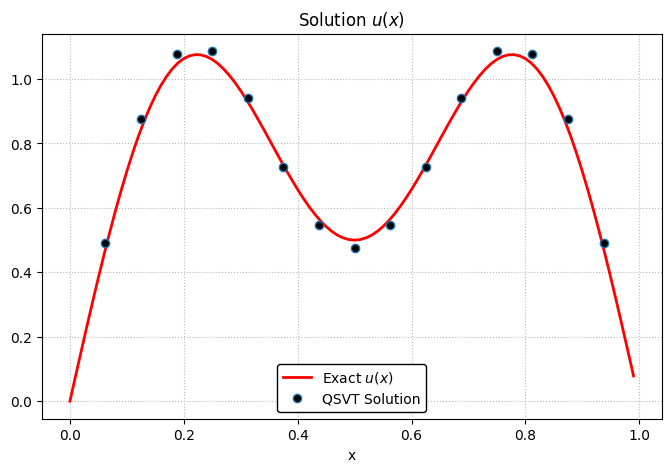

In [91]:
u_num_1 = one_d_dst_solver(15)

print(u_num_1)

x_exact_1 = np.linspace(0, 1, 100, endpoint=False)

x_mesh_1  = np.linspace(0, 1, 15 + 2)[1:-1]

epsilon = 1e-8

u_exact_1 = np.sin(np.pi * x_exact_1) + 0.5 * np.sin(3 * np.pi * x_exact_1)

u_mesh_1 = np.sin(np.pi * x_mesh_1) + 0.5 * np.sin(3 * np.pi * x_mesh_1)

error_u_1 = np.max(np.abs(u_num_1 - u_mesh_1))

print(f"最终解 u 的最大误差 (L-inf): {error_u_1:.5e}")

plt.figure(figsize=(8, 5))

# 绘制最终解 u
plt.plot(x_exact_1, u_exact_1, 'r-', linewidth=2, label='Exact $u(x)$')
plt.plot(x_mesh_1, u_num_1, 'o', markerfacecolor='black', label='QSVT Solution')
plt.title('Solution $u(x)$')
plt.xlabel('x')
plt.legend()
plt.grid(True)
plt.savefig('dst_bi.pdf', bbox_inches='tight')
plt.show()